## Hugging Face: BERT

In [2]:
import pandas as pd
all_data_df = pd.read_csv('all_data.csv')

In [33]:
print(all_data_df['text'].isna().sum())

981


In [34]:
all_data_df = all_data_df.dropna(subset=["text"])

In [35]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

def truncate_text(text, max_length=512):
    encoded = tokenizer.encode(
        str(text),
        max_length=max_length,
        truncation=True,
        add_special_tokens=True
    )
    return tokenizer.decode(encoded, skip_special_tokens=True)

all_data_df["truncated_text"] = all_data_df["text"].apply(truncate_text)


In [5]:
!pip install tqdm

In [38]:
from transformers import pipeline
from tqdm import tqdm
from tqdm import TqdmMonitorWarning

classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=0)

texts = all_data_df["truncated_text"].astype(str).tolist()
batch_size = 32
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Processing"):
    batch = texts[i:i+batch_size]
    batch_result = classifier(batch, truncation=True)
    results.extend(batch_result)

all_data_df["hf_sentiment"] = [r["score"] for r in results]


Device set to use cuda:0
Processing: 100%|██████████| 660/660 [03:31<00:00,  3.12it/s]


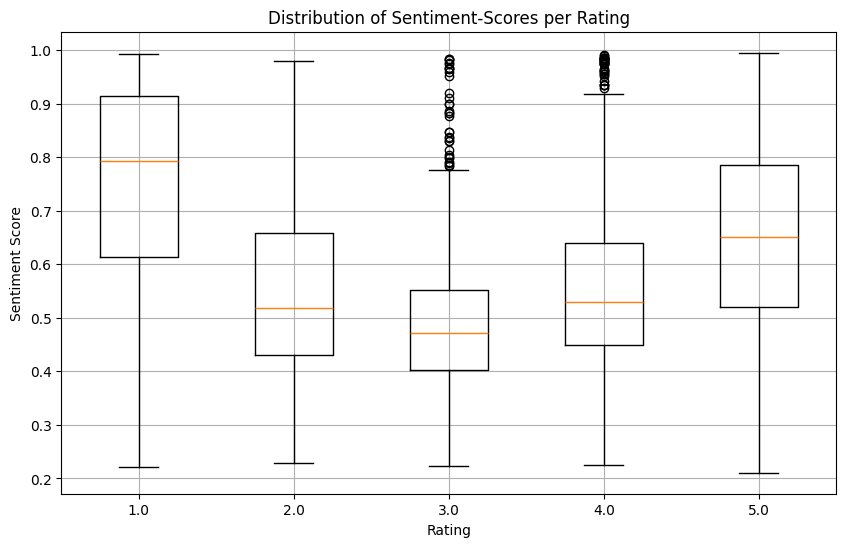

In [39]:
import matplotlib.pyplot as plt
import numpy as np

ratings = sorted(all_data_df["rating_x"].dropna().unique())
grouped_scores = [all_data_df[all_data_df["rating_x"] == r]["hf_sentiment"].dropna() for r in ratings]

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_scores, tick_labels=ratings)
plt.title("Distribution of Sentiment-Scores per Rating")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.grid(True)
plt.show()


In [44]:
all_data_df["hf_sentiment"] = [r["label"] for r in results]

In [47]:
all_data_df["rating_x"] = pd.to_numeric(all_data_df["rating_x"], errors='coerce')

all_data_df["hf_sentiment"] = all_data_df["hf_sentiment"].astype(str).str.extract(r"(\d)").astype(float)


mismatches = all_data_df[all_data_df["rating_x"] != all_data_df["hf_sentiment_num"]]


print(f"Not matching cases: {len(mismatches)} из {len(all_data_df)} ({len(mismatches)/len(all_data_df)*100:.2f}%)")


mismatches[["text", "rating_x", "hf_sentiment"]].sample(15)


Not matching cases: 4766 из 21098 (22.59%)


,text,rating_x,hf_sentiment
12951,Bed sheets were dirty. Bed downstairs had a ho...,3.0,1.0
9214,"Unexpected change of price, inability to commu...",2.0,1.0
5857,"It was very easy to book my park, sleep and fl...",5.0,4.0
17908,Simple sur le site,5.0,3.0
18372,Driver did not tag luggage and my bag was stol...,2.0,1.0
11258,The vehicle was damaged when rented to me and ...,2.0,1.0
15376,Good experience,5.0,4.0
17640,"The people have been fantastic, and so helpful...",4.0,2.0
19361,We booked hotel with hotel.com and I am holdin...,1.0,2.0
3349,Cheap price compare to other sites.,5.0,2.0


In [51]:
all_data_df = all_data_df.drop('hf_sentiment_num', axis=1)
all_data_df

,name,country,rating_x,title,text,date_of_experience,has_reply,company_x,company_y,website,rating_y,number_review,domain,5_star_percentage,4_star_percentage,3_star_percentage,2_star_percentage,1_star_percentage,truncated_text,hf_sentiment
0,Przemysław Rosuł,PL,1.0,Ignoring the specified pickup time,Ignoring the specified pickup time. Providing ...,2025-05-13,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,ignoring the specified pickup time. providing ...,1.0
1,kathy mrozek,US,5.0,Athens Evening food tour with Katrina,"Katrina, the tour guide was fabulous! She mad...",2025-05-15,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,"katrina, the tour guide was fabulous! she made...",5.0
2,MARY MURRAY,US,5.0,All you need for travel with confidence,A great app! My excursions have been awesome! ...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,a great app! my excursions have been awesome! ...,5.0
3,K Shay Smith,MX,1.0,I booked the excursion and paid the…,I booked the excursion and paid the money up f...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,i booked the excursion and paid the money up f...,1.0
4,Jeff Paine,US,5.0,Great food tour of Prague. Great conversation ...,Great food tour of Prague,2025-05-07,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,great food tour of prague,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21110,Asma,US,1.0,I rented a car with Expedia and paid…,I rented a car with Expedia and paid the money...,2025-02-08,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i rented a car with expedia and paid the money...,1.0
21111,Algirdas Dembinskas,US,1.0,Platinum user review,I’ve been using Expedia frequently for over 10...,2025-02-16,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i ve been using expedia frequently for over 10...,2.0
21112,Erin McLaughlin,US,1.0,NEVER book a flight through Expedia,NEVER book a flight through Expedia. “Fully re...,2025-02-15,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,never book a flight through expedia. fully ref...,1.0
21113,Lane Rosen,US,1.0,Expedia a Very deceptive company,Very deceptive company. Charge double the reg...,2025-02-14,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,very deceptive company. charge double the regu...,1.0


In [52]:
all_data_df.to_csv('reviews_data.csv', index=False)